In [2]:
### import  the  libraries   
import  pandas as  pd  
import  numpy  as  np   
import   matplotlib.pyplot  as  plt  
import  seaborn  as  sns  
import  missingno  as  msn    
### for  the  stats  plot   
from  scipy    import stats    

####  load  the   preprocessed  data sets   

In [3]:
data  =  pd.read_csv("../data/df_hospital.csv")   
data.head()    

,Facility ID,cleanliness,nurse_comm,doctor_comm,staff_responsiveness,quietness,welcoming_score,State,Hospital Type,Hospital Ownership,Emergency Services,Hospital overall rating,Safety of care national comparison,Patient experience national comparison,Effectiveness of care national comparison,Timeliness of care national comparison,Efficient use of medical imaging national comparison,Number of Completed Surveys,Survey Response Rate Percent
0,10001,88.0,90.0,91.0,83.0,86.0,87.6,AL,Acute Care Hospitals,Government - Hospital District or Authority,Yes,2.0,Same as the national average,Below the national average,Same as the national average,Same as the national average,Same as the national average,535.0,22.0
1,10005,87.0,92.0,93.0,85.0,84.0,88.2,AL,Acute Care Hospitals,Government - Hospital District or Authority,Yes,2.0,Same as the national average,Same as the national average,Same as the national average,Above the national average,Below the national average,1053.0,34.0
2,10006,82.0,90.0,93.0,79.0,85.0,85.8,AL,Acute Care Hospitals,Proprietary,Yes,2.0,Same as the national average,Below the national average,Same as the national average,Above the national average,Below the national average,664.0,24.0
3,10007,91.0,91.0,92.0,86.0,86.0,89.2,AL,Acute Care Hospitals,Voluntary non-profit - Private,Yes,2.0,Same as the national average,Same as the national average,Below the national average,Above the national average,Same as the national average,163.0,26.0
4,10011,85.0,90.0,92.0,85.0,83.0,87.0,AL,Acute Care Hospitals,Voluntary non-profit - Private,Yes,2.0,Below the national average,Below the national average,Below the national average,Below the national average,Same as the national average,2162.0,32.0


In [4]:
data.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3175 entries, 0 to 3174
Data columns (total 19 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Facility ID                                           3175 non-null   int64  
 1   cleanliness                                           3175 non-null   float64
 2   nurse_comm                                            3175 non-null   float64
 3   doctor_comm                                           3175 non-null   float64
 4   staff_responsiveness                                  3175 non-null   float64
 5   quietness                                             3175 non-null   float64
 6   welcoming_score                                       3175 non-null   float64
 7   State                                                 3175 non-null   object 
 8   Hospital Type                                         3175

In [ ]:
target_variable  =  "Hospital overall rating"   


In [ ]:
freq_table = data['Hospital overall rating'].value_counts().sort_index()
percent_table = data['Hospital overall rating'].value_counts(normalize=True).sort_index() * 100

freq_df = pd.DataFrame({
    'Count': freq_table,
    'Percentage (%)': percent_table
})
print("Frequency Table for Hospital overall rating (1-5 stars):")
print(freq_df)
print()

Frequency Table for Hospital overall rating (1-5 stars):
                         Count  Percentage (%)
Hospital overall rating                       
1.0                        220        6.929134
2.0                        654       20.598425
3.0                        919       28.944882
4.0                        983       30.960630
5.0                        399       12.566929



C:\Users\ASUS\AppData\Local\Temp\ipykernel_27240\3686373304.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hospital overall rating', data=data, palette='viridis', order=sorted(data['Hospital overall rating'].unique()))


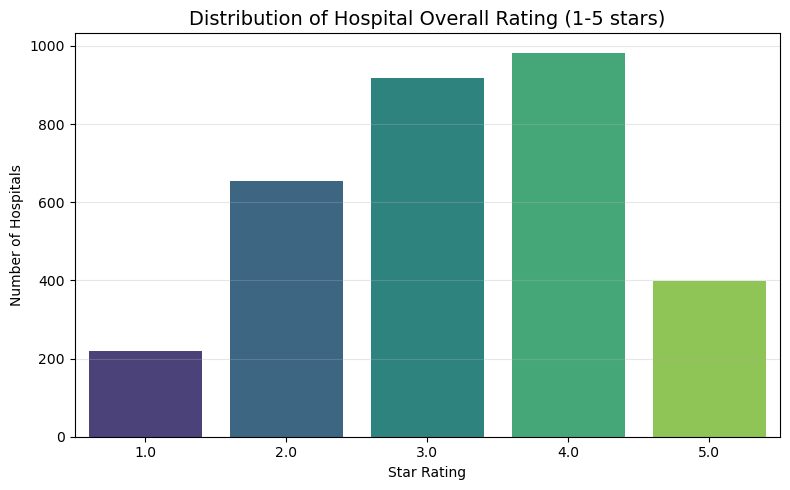

In [15]:
###  create  the  bar  charts 

plt.figure(figsize=(8,5))
sns.countplot(x='Hospital overall rating', data=data, palette='viridis', order=sorted(data['Hospital overall rating'].unique()))
plt.title('Distribution of Hospital Overall Rating (1-5 stars)', fontsize=14)
plt.xlabel('Star Rating')
plt.ylabel('Number of Hospitals')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/bar_star_ratings.png', dpi=150)
plt.show()

In [19]:
predictive_variable  =   'welcoming_score'   

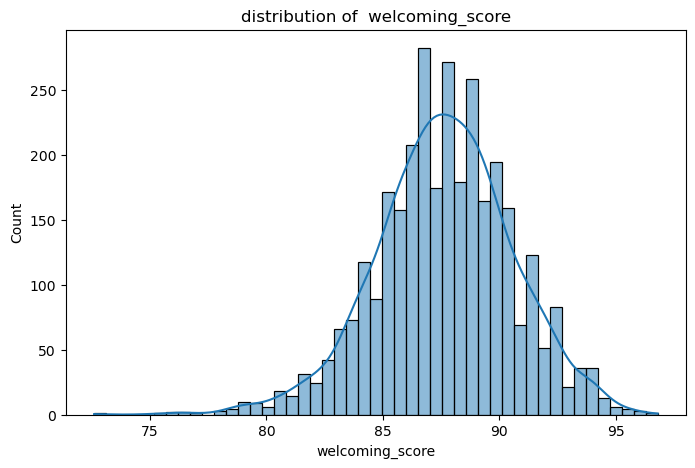

In [21]:
###  create  the  hist  plots    
plt.figure(figsize=(8,5))    
sns.histplot(data["welcoming_score"]  , kde  = True)   
plt.title("distribution of  welcoming_score")   
plt.show()   

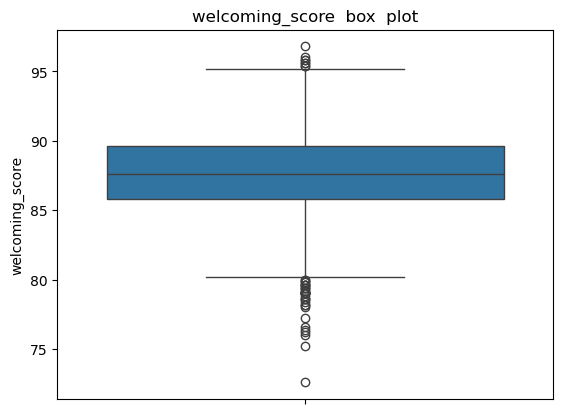

In [22]:
###  create  the  box  plot   
plt.Figure(figsize=(8,5))    
sns.boxplot(y  =  data["welcoming_score"] )    
plt.title("welcoming_score  box  plot")    
plt.show()    

###  Descriptive  for  main   varibales   

In [25]:
main_cols  =  ['cleanliness', 'nurse_comm', 'doctor_comm',
       'staff_responsiveness', 'quietness'  ,  'Hospital overall rating']     

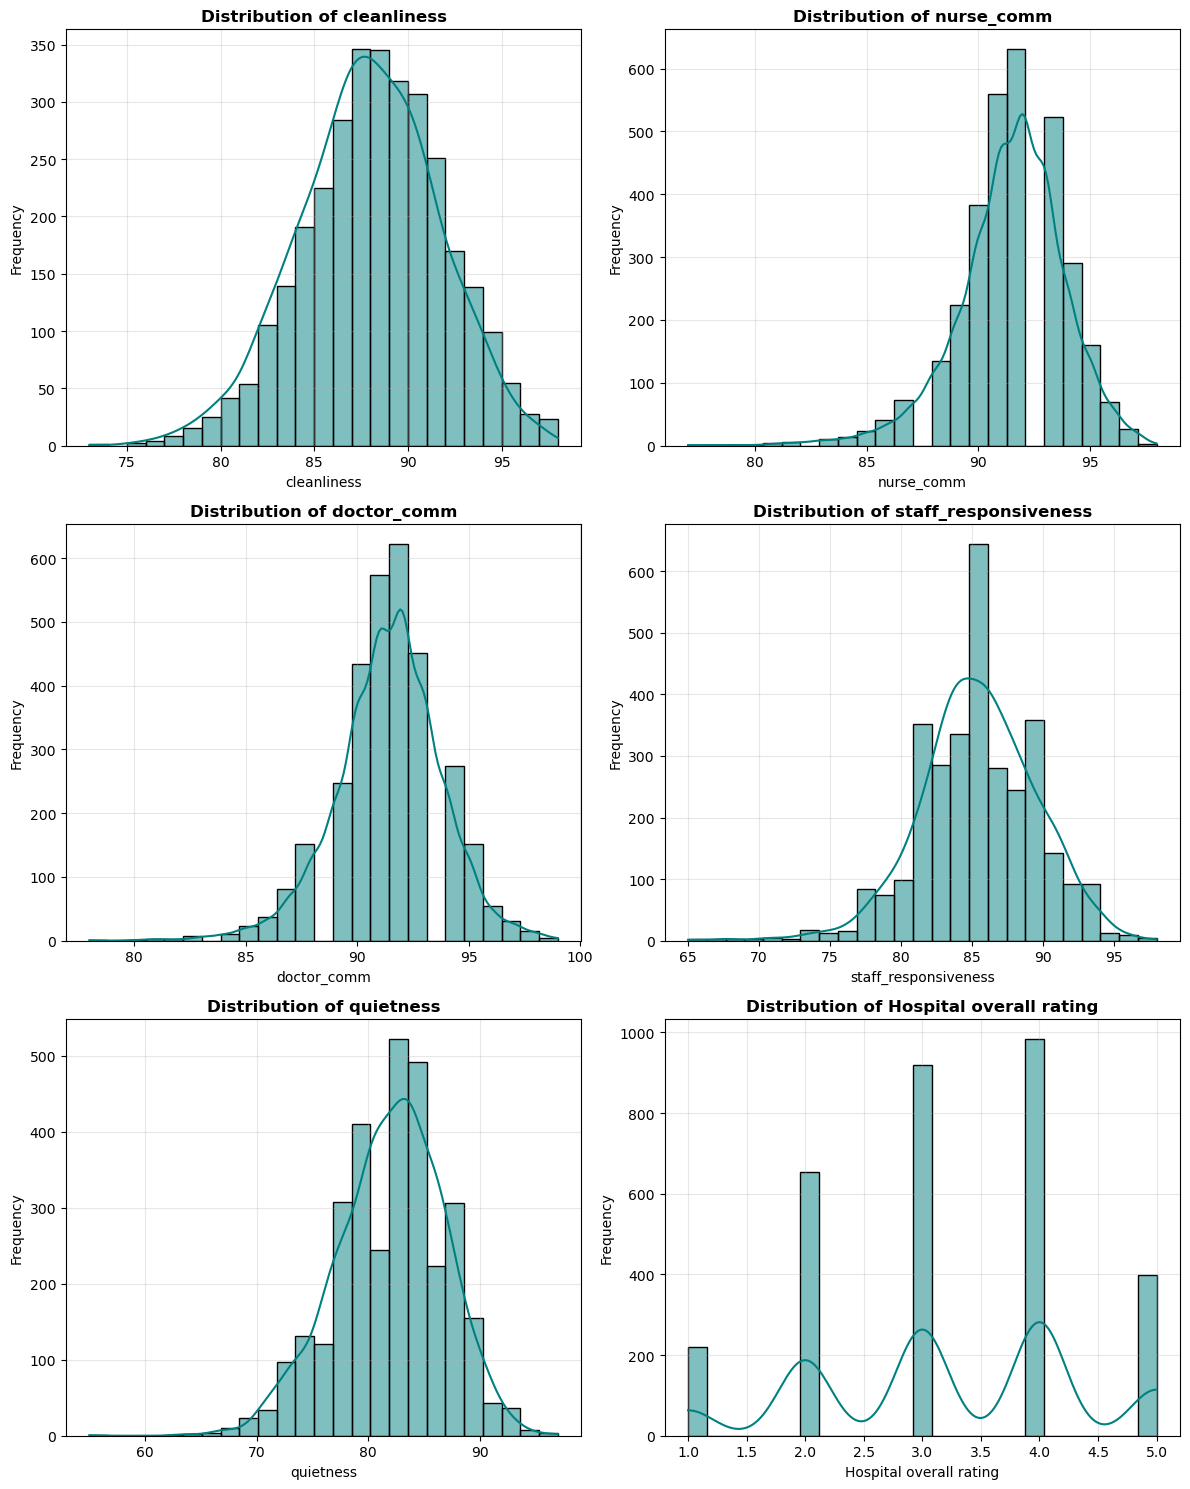

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the grid (3 rows, 2 columns)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 15))

# Flatten the axes array to easily iterate over it
axes = axes.flatten()

for i, col in enumerate(main_cols):
    # Select the current axis
    ax = axes[i]
    
    # Plot on the specific axis 'ax'
    sns.histplot(data[col], kde=True, color='teal', edgecolor='black', bins=25, ax=ax)
    
    # Formatting
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.3)

# Remove any empty subplots if main_cols has fewer than 6 items
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('../reports/figures/combined_distributions.png', dpi=150)
plt.show()